# Gaussian Mixture Model (GMM) Workflow for Astronomical Object Clustering

This notebook is a **focused GMM workflow** for clustering astronomical objects.

- it uses **one feature set only**
- it keeps the **same evaluation family** used in the earlier notebook
- it uses the **scaled data already prepared by the team**
- it adds a more explicit **model-selection narrative** for:
  1. why GMM is appropriate,
  2. how to choose the number of components \(K\),
  3. how to choose the covariance structure,
  4. how to justify the remaining hyperparameters,
  5. how to evaluate the final fitted model(s).

## Fixed feature set used in this notebook

Per project decision, the model is trained on:

- `u-g`
- `g-r`
- `r-i`
- `i-z`
- `redshift_log`

This is effectively **Set B**, but with **`redshift_log` replacing raw redshift**. No new feature engineering is introduced here.

## 1. Pipeline overview

The end-to-end pipeline in this notebook is:

1. **Load the team's scaled dataset** from `../Set_D.csv`.
2. **Restrict the feature matrix** to the agreed columns:
   `['u-g', 'g-r', 'r-i', 'i-z', 'redshift_log']`.
3. **Justify GMM** as a probabilistic alternative to K-Means when class boundaries are blurred and cluster covariance matters.
4. **Select the number of components \(K\)** using **BIC** as the primary criterion and **AIC** as a supporting criterion.
5. **Always attempt \(K=3\)** because it is the domain-grounded candidate, then decide whether a second branch is needed if a different \(K\) is materially better.
6. **Compare covariance structures** and verify whether `full` is preferred.
7. **Fix the remaining hyperparameters** (`n_init`, `reg_covar`, `max_iter`, `init_params`, `random_state`)
8. **Fit the final GMM model(s)**.
9. **Evaluate them** using the same family of metrics as the other models  :
   silhouette, Davies–Bouldin, Calinski–Harabasz, ARI, NMI, purity, cluster composition, PCA visualisation, and membership-probability analysis.
10. **Interpret the results** in terms of overlap between stars, galaxies, and quasars.


In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)
from sklearn.decomposition import PCA

## 2. Load feature matrix

In [2]:
# -------------------------------------------------------------------
# Configuration
# -------------------------------------------------------------------
SCALED_FEATURE_PATH = Path("../astral_data.csv")
RAW_LABEL_PATH = Path("../star-galaxy-quasar.csv")

FEATURE_COLS = ['u-g', 'g-r', 'r-i', 'i-z', 'redshift_log']
TARGET_COL = "class"

# -------------------------------------------------------------------
# Load the team's scaled feature table
# -------------------------------------------------------------------
scaled_df = pd.read_csv(SCALED_FEATURE_PATH)

missing_features = [c for c in FEATURE_COLS if c not in scaled_df.columns]
if missing_features:
    raise ValueError(
        f"Missing expected feature columns in {SCALED_FEATURE_PATH}: {missing_features}"
    )

X = scaled_df[FEATURE_COLS].copy()

if TARGET_COL in scaled_df.columns:
    y = scaled_df[TARGET_COL].copy()
else:
    raw_labels = pd.read_csv(RAW_LABEL_PATH, skiprows=1)
    if TARGET_COL not in raw_labels.columns:
        raise ValueError(f"Could not find '{TARGET_COL}' in {RAW_LABEL_PATH}")
    if len(raw_labels) != len(scaled_df):
        raise ValueError(
            "Scaled feature table and raw label table have different row counts. "
            "Please verify row alignment before proceeding."
        )
    y = raw_labels[TARGET_COL].copy()

print("Feature matrix shape:", X.shape)
print("Feature columns:", FEATURE_COLS)
print("\nClass distribution:")
print(y.value_counts(dropna=False))
X.head()

Feature matrix shape: (9733, 5)
Feature columns: ['u-g', 'g-r', 'r-i', 'i-z', 'redshift_log']

Class distribution:
class
GALAXY    8423
QSO        685
STAR       625
Name: count, dtype: int64


,u-g,g-r,r-i,i-z,redshift_log
0,0.282719,0.199441,0.311683,0.203881,-0.145579
1,0.082746,0.183756,1.123312,0.428709,-0.549480
2,-0.312019,-0.067587,-0.128764,0.126954,-0.235675
3,0.397933,0.144873,0.426494,0.523488,-0.196892
4,-0.264895,-0.435012,-0.160010,-0.758546,-0.328149


## 3. Why try a Gaussian Mixture Model?

The K-Means section already established an important limitation: centroid-based clustering can recover the strongest large-scale structure, but it may struggle when **class boundaries are not sharp**.


In this dataset, stars, galaxies, and QSOs are not expected to form perfectly separated spherical clouds in feature space:

- colour indices can overlap,
- redshift helps but may not fully separate stars from galaxies,
- astrophysical populations can show different variances and correlations.

K-Means assigns each point to the nearest centroid and implicitly favors spherical clusters.  
GMM instead models the data as a weighted mixture of multivariate Gaussian components:



That gives three practical advantages here:

1. **Soft assignments**: each object gets a membership probability instead of a forced hard label.
2. **Flexible cluster geometry**: clusters can be elliptical rather than spherical.
3. **Better treatment of blurred boundaries**: ambiguous objects can be represented as uncertain rather than artificially forced into a single clean cluster.

This is potentially useful for astronomical data because uncertainty and overlap is present from the scientific observations

## 4. Choosing the number of components \(K\)

This notebook uses **BIC** as the main model-selection criterion and **AIC** as a supporting criterion.

A standard review of mixture-model selection describes AIC and BIC as **"popular model selection criteria"** for choosing a parsimonious model.  
Source: Celeux, Fruhwirth-Schnatter & Robert, *Model Selection for Mixture Models* (2018).
### Why BIC and AIC?

Both criteria reward better fit through the likelihood term, but penalize added complexity through the parameter count.


### How we will decide here

1. Fit GMMs across a grid of \(K\) values using **`covariance_type='full'`** as the initial, most flexible baseline.
2. Plot and tabulate BIC and AIC.
3. Inspect the **marginal gains** from increasing \(K\).
4. Always keep **\(K=3\)** in view because it is the domain-grounded candidate.
5. If \(K=3\) is not the BIC optimum, build **two branches**:
   - one model with \(K=3\),
   - one model with the better-supported \(K\).

We do not assume the ground truth should automatically win, but do test whether it remains a reasonable choice.

In [3]:
def fit_k_scan(
    X: pd.DataFrame,
    k_values=range(1, 21),
    covariance_type: str = "full",
    n_init: int = 20,
    reg_covar: float = 1e-6,
    max_iter: int = 500,
    random_state: int = 42,
):
    """Fit a sequence of GMMs for model-order selection."""
    rows = []
    models = {}

    for k in k_values:
        model = GaussianMixture(
            n_components=k,
            covariance_type=covariance_type,
            n_init=n_init,
            reg_covar=reg_covar,
            max_iter=max_iter,
            init_params="kmeans",
            random_state=random_state,
        )
        model.fit(X)

        bic = model.bic(X)
        aic = model.aic(X)

        rows.append({
            "k": k,
            "bic": bic,
            "aic": aic,
            "avg_log_likelihood": model.score(X),
            "n_parameters": model._n_parameters(),
        })
        models[k] = model

    out = pd.DataFrame(rows).sort_values("k").reset_index(drop=True)

    out["bic_improvement_vs_prev"] = out["bic"].shift(1) - out["bic"]
    out["aic_improvement_vs_prev"] = out["aic"].shift(1) - out["aic"]
    out["delta_bic_from_best"] = out["bic"] - out["bic"].min()
    out["delta_aic_from_best"] = out["aic"] - out["aic"].min()

    return out, models


k_scan_results, k_scan_models = fit_k_scan(X)

display(k_scan_results.style.format({
    "bic": "{:,.2f}",
    "aic": "{:,.2f}",
    "avg_log_likelihood": "{:.6f}",
    "bic_improvement_vs_prev": "{:,.2f}",
    "aic_improvement_vs_prev": "{:,.2f}",
    "delta_bic_from_best": "{:,.2f}",
    "delta_aic_from_best": "{:,.2f}",
}))

,k,bic,aic,avg_log_likelihood,n_parameters,bic_improvement_vs_prev,aic_improvement_vs_prev,delta_bic_from_best,delta_aic_from_best
0,1,"130,310.36","130,166.69",-6.684819,20,nan,nan,"76,904.38","79,753.68"
1,2,"89,083.95","88,789.43",-4.557045,41,"41,226.41","41,377.26","35,677.97","38,376.42"
2,3,"81,054.20","80,608.83",-4.134636,62,"8,029.75","8,180.60","27,648.22","30,195.82"
3,4,"73,177.01","72,580.80",-3.720066,83,"7,877.19","8,028.04","19,771.03","22,167.78"
4,5,"69,332.21","68,585.15",-3.512645,104,"3,844.80","3,995.65","15,926.23","18,172.13"
5,6,"64,719.40","63,821.49",-3.265770,125,"4,612.81","4,763.66","11,313.42","13,408.47"
6,7,"62,215.23","61,166.47",-3.127220,146,"2,504.16","2,655.01","8,809.26","10,753.46"
7,8,"59,992.72","58,793.11",-3.003139,167,"2,222.52","2,373.36","6,586.74","8,380.10"
8,9,"58,883.52","57,533.06",-2.936251,188,"1,109.20","1,260.05","5,477.54","7,120.05"
9,10,"57,285.00","55,783.69",-2.844225,209,"1,598.52","1,749.37","3,879.02","5,370.68"


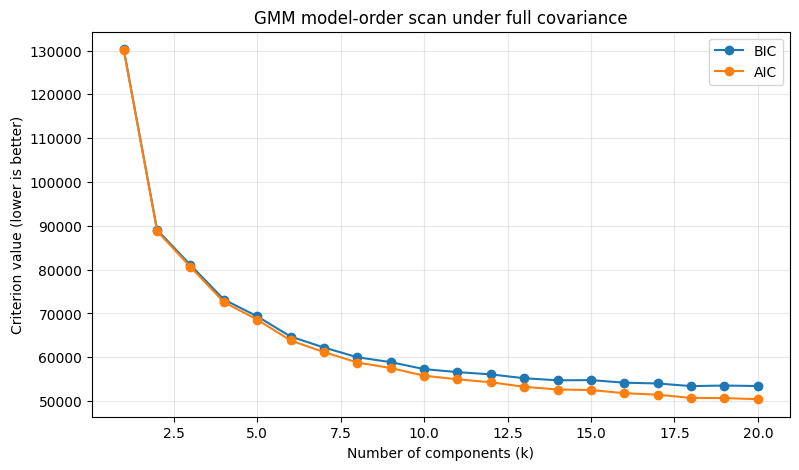

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(k_scan_results["k"], k_scan_results["bic"], marker="o", label="BIC")
ax.plot(k_scan_results["k"], k_scan_results["aic"], marker="o", label="AIC")
ax.set_title("GMM model-order scan under full covariance")
ax.set_xlabel("Number of components (k)")
ax.set_ylabel("Criterion value (lower is better)")
ax.grid(alpha=0.3)
ax.legend()
plt.show()

### Interpreting the \(K\)-selection output

At this point, the decision logic is:

- **If BIC is minimized at \(K=3\)**, then the simpler domain-grounded story is retained and only one branch is built.
- **If BIC prefers another \(K\)**, then we still keep \(K=3\) as a comparison branch and fit a second model at the BIC-preferred \(K\).


In [16]:
bic_best_k = int(k_scan_results.loc[k_scan_results["bic"].idxmin(), "k"])
aic_best_k = int(k_scan_results.loc[k_scan_results["aic"].idxmin(), "k"])

print(f"BIC-optimal k: {bic_best_k}")
print(f"AIC-optimal k: {aic_best_k}")

if bic_best_k == 3:
    candidate_ks = [3]
    print("\nDecision: retain a single branch with k = 3 (BIC primary).")
else:
    candidate_ks = sorted({3, 4})
    print(f"\nDecision: build two branches for comparison: k = {candidate_ks}")

BIC-optimal k: 18
AIC-optimal k: 20

Decision: build two branches for comparison: k = [3, 4]


## 5. Choosing the covariance structure

Once the candidate \(K\) values are fixed, the next step is to decide how flexible each component covariance matrix should be.

The four common options are:

- `spherical`: one variance per component,
- `diag`: one variance per feature per component, but no covariance terms,
- `tied`: a single covariance matrix shared across all components,
- `full`: each component has its own full covariance matrix.

### Why `full` is a strong candidate here

For astronomical colour features, correlations are scientifically plausible. A model that forbids covariance terms can be too restrictive.

A recent astronomy mixture-model application states:  
**"each component has its own general covariance matrix"** when using the `full` form.  
Source: Ansari et al., *Mixture models for photometric redshifts* (2021), A&A.

That is exactly the flexibility we want if different populations occupy elongated or tilted regions in colour–redshift space.

### Decision principle used here

We do **not** hard-code `full` by assumption alone. Instead we compare covariance families empirically for each candidate \(K\), again using:

- **BIC as the primary criterion**
- **AIC as a supporting criterion**

If `full` wins, we can justify it both:
1. statistically, because it scores best;
2. scientifically, because correlated astronomical features make it plausible.

In [17]:
def compare_covariances(
    X: pd.DataFrame,
    k_values,
    covariance_types=("full", "tied", "diag", "spherical"),
    n_init: int = 20,
    reg_covar: float = 1e-6,
    max_iter: int = 500,
    random_state: int = 42,
):
    """Compare covariance structures for each candidate k."""
    rows = []
    models = {}

    for k in k_values:
        for cov in covariance_types:
            model = GaussianMixture(
                n_components=k,
                covariance_type=cov,
                n_init=n_init,
                reg_covar=reg_covar,
                max_iter=max_iter,
                init_params="kmeans",
                random_state=random_state,
            )
            model.fit(X)

            rows.append({
                "k": k,
                "covariance_type": cov,
                "bic": model.bic(X),
                "aic": model.aic(X),
                "avg_log_likelihood": model.score(X),
                "n_parameters": model._n_parameters(),
            })
            models[(k, cov)] = model

    out = pd.DataFrame(rows).sort_values(["k", "bic", "aic"]).reset_index(drop=True)
    return out, models


cov_results, cov_models = compare_covariances(X, candidate_ks)

display(cov_results.style.format({
    "bic": "{:,.2f}",
    "aic": "{:,.2f}",
    "avg_log_likelihood": "{:.6f}",
}))

,k,covariance_type,bic,aic,avg_log_likelihood,n_parameters
0,3,full,"81,054.20","80,608.83",-4.134636,62
1,3,diag,"109,081.96","108,852.10",-5.588621,32
2,3,tied,"114,621.58","114,391.71",-5.873200,32
3,3,spherical,"117,079.71","116,936.05",-6.005139,20
4,4,full,"73,177.01","72,580.80",-3.720066,83
5,4,diag,"96,416.50","96,107.62",-4.932786,43
6,4,spherical,"108,936.26","108,742.31",-5.583495,27
7,4,tied,"110,823.21","110,550.24",-5.675241,38


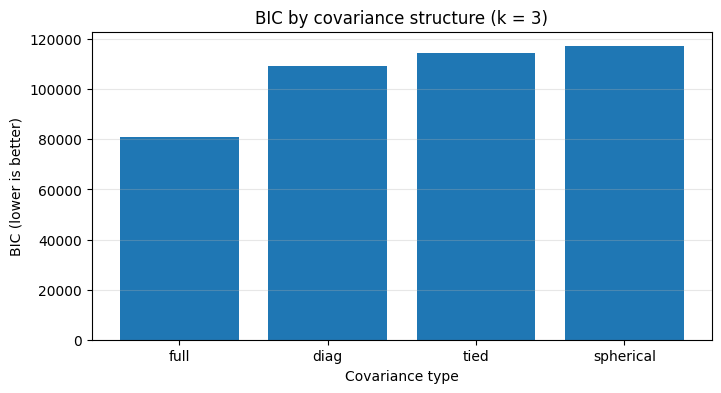

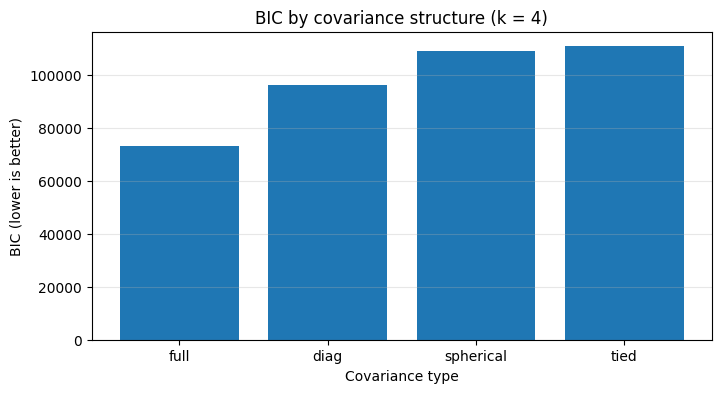

In [18]:
for k in candidate_ks:
    subset = cov_results[cov_results["k"] == k].sort_values("bic")

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(subset["covariance_type"], subset["bic"])
    ax.set_title(f"BIC by covariance structure (k = {k})")
    ax.set_xlabel("Covariance type")
    ax.set_ylabel("BIC (lower is better)")
    ax.grid(axis="y", alpha=0.3)
    plt.show()

In [19]:
best_cov_by_k = (
    cov_results.sort_values(["k", "bic", "aic"])
    .groupby("k", as_index=False)
    .first()[["k", "covariance_type", "bic", "aic"]]
)

print("Best covariance type by candidate k:")
display(best_cov_by_k)

Best covariance type by candidate k:


,k,covariance_type,bic,aic
0,3,full,81054.195948,80608.832746
1,4,full,73177.009142,72580.797113


## 6. Other hyperparameters

The remaining hyperparameters are chosen to make the fitting process more stable rather than to materially change the model class.

### `n_init = 20`
Expectation–Maximization can converge to local optima. Using multiple initializations reduces the chance that a poor local solution is mistaken for the final answer.

### `init_params = 'kmeans'`
This gives EM a more stable starting partition than a purely random initialization.

### `reg_covar = 1e-6`
This adds a very small ridge term to each covariance matrix. It is mainly a numerical safeguard against nearly singular covariance estimates.

### `max_iter = 500`
This is a conservative upper bound so the optimization is unlikely to stop prematurely.

### `random_state = 42`
This is included purely for reproducibility.

These settings are deliberately practical rather than exotic: the main substantive choices in this notebook are still **\(K\)** and **covariance structure**.

In [20]:
FINAL_N_INIT = 20
FINAL_REG_COVAR = 1e-6
FINAL_MAX_ITER = 500
FINAL_INIT_PARAMS = "kmeans"
FINAL_RANDOM_STATE = 42

## 7. Fit the final models

For each candidate \(K\):

1. select the best covariance structure by BIC,
2. fit the final model,
3. evaluate it with the same metric family used in the earlier notebook.



In [21]:
def purity_score(y_true, y_pred):
    contingency = pd.crosstab(
        pd.Series(y_true, name="true"),
        pd.Series(y_pred, name="cluster")
    )
    return contingency.max(axis=0).sum() / contingency.values.sum()


def cluster_label_mapping(y_true, cluster_labels):
    contingency = pd.crosstab(
        pd.Series(y_true, name="true"),
        pd.Series(cluster_labels, name="cluster")
    )
    mapping = contingency.idxmax(axis=0).to_dict()
    mapped_labels = pd.Series(cluster_labels).map(mapping)
    return mapping, mapped_labels, contingency


def normalized_entropy(proba):
    proba = np.clip(proba, 1e-12, 1.0)
    ent = -(proba * np.log(proba)).sum(axis=1)
    return ent / np.log(proba.shape[1])


def evaluate_gmm(model, X: pd.DataFrame, y: pd.Series):
    cluster_labels = model.predict(X)
    proba = model.predict_proba(X)

    metrics = {
        "k": model.n_components,
        "covariance_type": model.covariance_type,
        "bic": model.bic(X),
        "aic": model.aic(X),
        "avg_log_likelihood": model.score(X),
        "ari": adjusted_rand_score(y, cluster_labels),
        "nmi": normalized_mutual_info_score(y, cluster_labels),
        "purity": purity_score(y, cluster_labels),
    }

    n_clusters_found = len(np.unique(cluster_labels))
    if n_clusters_found > 1:
        metrics["silhouette"] = silhouette_score(X, cluster_labels)
        metrics["davies_bouldin"] = davies_bouldin_score(X, cluster_labels)
        metrics["calinski_harabasz"] = calinski_harabasz_score(X, cluster_labels)
    else:
        metrics["silhouette"] = np.nan
        metrics["davies_bouldin"] = np.nan
        metrics["calinski_harabasz"] = np.nan

    confidence = proba.max(axis=1)
    entropy = normalized_entropy(proba)

    metrics["mean_max_membership_prob"] = confidence.mean()
    metrics["median_max_membership_prob"] = np.median(confidence)
    metrics["mean_membership_entropy"] = entropy.mean()
    metrics["share_low_confidence_<0.60"] = (confidence < 0.60).mean()
    metrics["share_low_confidence_<0.80"] = (confidence < 0.80).mean()

    mapping, mapped_labels, contingency = cluster_label_mapping(y, cluster_labels)

    diagnostics = pd.DataFrame({
        "true_class": y.values,
        "cluster": cluster_labels,
        "predicted_majority_class": mapped_labels.values,
        "max_membership_prob": confidence,
        "membership_entropy": entropy,
    })

    diagnostics["is_majority_vote_correct"] = (
        diagnostics["true_class"] == diagnostics["predicted_majority_class"]
    )

    return metrics, diagnostics, contingency, mapping


final_models = {}
final_results = []
final_diagnostics = {}
final_contingencies = {}
final_mappings = {}

for k in candidate_ks:
    chosen_cov = (
        best_cov_by_k.loc[best_cov_by_k["k"] == k, "covariance_type"]
        .iloc[0]
    )

    model = GaussianMixture(
        n_components=k,
        covariance_type=chosen_cov,
        n_init=FINAL_N_INIT,
        reg_covar=FINAL_REG_COVAR,
        max_iter=FINAL_MAX_ITER,
        init_params=FINAL_INIT_PARAMS,
        random_state=FINAL_RANDOM_STATE,
    )
    model.fit(X)

    metrics, diagnostics, contingency, mapping = evaluate_gmm(model, X, y)

    final_models[k] = model
    final_results.append(metrics)
    final_diagnostics[k] = diagnostics
    final_contingencies[k] = contingency
    final_mappings[k] = mapping

final_results_df = pd.DataFrame(final_results).sort_values("bic").reset_index(drop=True)
display(final_results_df.style.format({
    "bic": "{:,.2f}",
    "aic": "{:,.2f}",
    "avg_log_likelihood": "{:.6f}",
    "ari": "{:.4f}",
    "nmi": "{:.4f}",
    "purity": "{:.4f}",
    "silhouette": "{:.4f}",
    "davies_bouldin": "{:.4f}",
    "calinski_harabasz": "{:,.2f}",
    "mean_max_membership_prob": "{:.4f}",
    "median_max_membership_prob": "{:.4f}",
    "mean_membership_entropy": "{:.4f}",
    "share_low_confidence_<0.60": "{:.2%}",
    "share_low_confidence_<0.80": "{:.2%}",
}))

,k,covariance_type,bic,aic,avg_log_likelihood,ari,nmi,purity,silhouette,davies_bouldin,calinski_harabasz,mean_max_membership_prob,median_max_membership_prob,mean_membership_entropy,share_low_confidence_<0.60,share_low_confidence_<0.80
0,4,full,"73,177.01","72,580.80",-3.720066,0.3977,0.3789,0.9063,0.3600,2.3777,"2,144.43",0.9589,0.9981,0.0779,2.02%,7.76%
1,3,full,"81,054.20","80,608.83",-4.134636,0.4619,0.4321,0.8915,0.3806,1.8813,"1,742.26",0.9719,0.9988,0.0694,1.66%,5.15%


## 8. Evaluation logic

The evaluation keeps the same metric family as the earlier notebook so that the GMM section remains directly comparable to the K-Means section.

### Internal metrics
- **Silhouette**: higher is better.
- **Davies–Bouldin**: lower is better.
- **Calinski–Harabasz**: higher is better.

These describe geometric separation in feature space, but they do not know the true class labels.

### External metrics
- **ARI** and **NMI** compare the clusters with the spectroscopic class labels.
- **Purity** measures how concentrated each cluster is with respect to a single class.

These are appropriate here because the labels are used **only for post-hoc evaluation**, not during fitting.

### Why we also analyze membership probabilities
This is the main value-add over K-Means.

A hard clustering summary can hide an important astrophysical fact: some objects may genuinely sit near boundaries.  
So instead of only asking *which cluster was assigned?*, we also ask:

- how confident was the assignment?
- how many objects are low-confidence?
- which true classes produce the most ambiguous memberships?
- are misclassified objects also the most uncertain?

This helps distinguish:
- a genuinely clean cluster structure,
- from a cluster structure that only looks clean after forcing hard labels.

In [22]:
for k in candidate_ks:
    print(f"\n=== Cluster composition for k = {k} ===")
    print("Majority-vote mapping:", final_mappings[k])
    display(final_contingencies[k])


=== Cluster composition for k = 3 ===
Majority-vote mapping: {0: 'GALAXY', 1: 'GALAXY', 2: 'QSO'}


cluster,0,1,2
true,,,
GALAXY,6890,1150,383
QSO,25,23,637
STAR,0,0,625



=== Cluster composition for k = 4 ===
Majority-vote mapping: {0: 'GALAXY', 1: 'GALAXY', 2: 'QSO', 3: 'STAR'}


cluster,0,1,2,3
true,,,,
GALAXY,1287,6467,255,414
QSO,2,35,579,69
STAR,0,0,137,488


In [23]:
# A compact side-by-side summary focused on the most report-relevant numbers
summary_cols = [
    "k",
    "covariance_type",
    "bic",
    "aic",
    "ari",
    "nmi",
    "purity",
    "silhouette",
    "davies_bouldin",
    "calinski_harabasz",
    "mean_max_membership_prob",
    "mean_membership_entropy",
]

display(final_results_df[summary_cols].sort_values("bic").style.format({
    "bic": "{:,.2f}",
    "aic": "{:,.2f}",
    "ari": "{:.4f}",
    "nmi": "{:.4f}",
    "purity": "{:.4f}",
    "silhouette": "{:.4f}",
    "davies_bouldin": "{:.4f}",
    "calinski_harabasz": "{:,.2f}",
    "mean_max_membership_prob": "{:.4f}",
    "mean_membership_entropy": "{:.4f}",
}))

,k,covariance_type,bic,aic,ari,nmi,purity,silhouette,davies_bouldin,calinski_harabasz,mean_max_membership_prob,mean_membership_entropy
0,4,full,"73,177.01","72,580.80",0.3977,0.3789,0.9063,0.3600,2.3777,"2,144.43",0.9589,0.0779
1,3,full,"81,054.20","80,608.83",0.4619,0.4321,0.8915,0.3806,1.8813,"1,742.26",0.9719,0.0694


## 9. Membership-probability analysis (value-add over K-Means)

This section goes beyond a single hard label and studies the **confidence profile** of each model.

Two diagnostics are used:

1. **Maximum membership probability**  
   For each object, this is the largest posterior probability assigned by the GMM.
   - closer to 1 → highly confident assignment,
   - closer to \(1/K\) → ambiguous assignment.

2. **Normalized membership entropy**  
   This summarizes how spread out the posterior probabilities are.
   - closer to 0 → confident,
   - closer to 1 → diffuse and uncertain.

### Why this matters scientifically

If a model appears to perform moderately on ARI/NMI but most errors occur at low confidence, that is a very different story from a model that is confidently wrong.  
In the first case, the GMM is correctly signaling boundary ambiguity.  
In the second case, the model structure itself is probably misspecified.

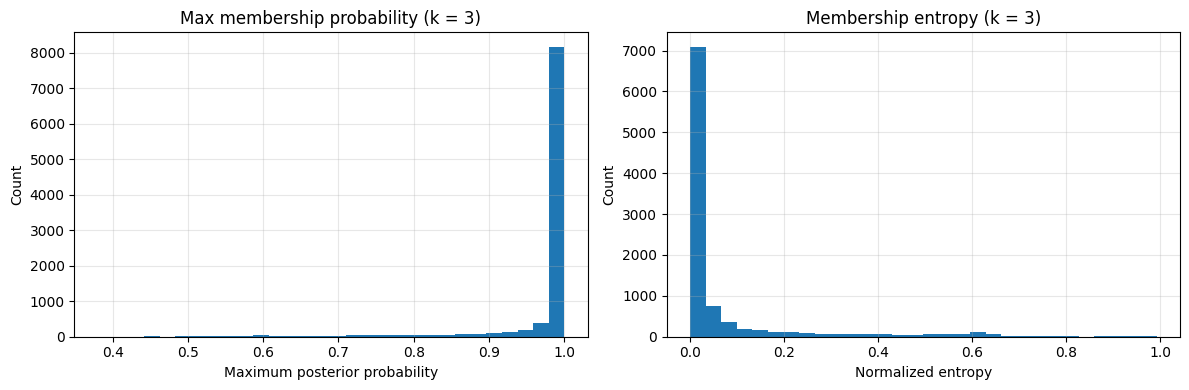

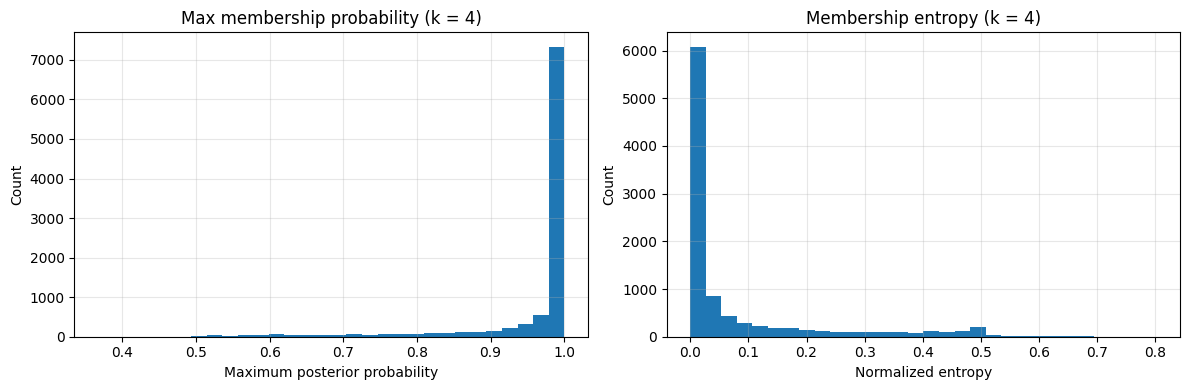

In [24]:
for k in candidate_ks:
    diag = final_diagnostics[k].copy()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].hist(diag["max_membership_prob"], bins=30)
    axes[0].set_title(f"Max membership probability (k = {k})")
    axes[0].set_xlabel("Maximum posterior probability")
    axes[0].set_ylabel("Count")
    axes[0].grid(alpha=0.3)

    axes[1].hist(diag["membership_entropy"], bins=30)
    axes[1].set_title(f"Membership entropy (k = {k})")
    axes[1].set_xlabel("Normalized entropy")
    axes[1].set_ylabel("Count")
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

In [25]:
probability_summary_rows = []

for k in candidate_ks:
    diag = final_diagnostics[k].copy()

    by_true_class = (
        diag.groupby("true_class")[["max_membership_prob", "membership_entropy", "is_majority_vote_correct"]]
        .agg({
            "max_membership_prob": ["mean", "median"],
            "membership_entropy": ["mean", "median"],
            "is_majority_vote_correct": "mean",
        })
    )

    print(f"\n=== Membership-probability summary by true class (k = {k}) ===")
    display(by_true_class)

    uncertain = diag.sort_values(
        ["max_membership_prob", "membership_entropy"],
        ascending=[True, False]
    ).head(15)

    print(f"Most ambiguous objects for k = {k}:")
    display(uncertain)


=== Membership-probability summary by true class (k = 3) ===


max_membership_prob           membership_entropy                \
                          mean    median               mean        median   
true_class                                                                  
GALAXY                0.969122  0.998261       7.678370e-02  1.194386e-02   
QSO                   0.980188  1.000000       4.197606e-02  5.030168e-11   
STAR                  1.000000  1.000000       5.030168e-11  5.030168e-11   

           is_majority_vote_correct  
                               mean  
true_class                           
GALAXY                     0.954529  
QSO                        0.929927  
STAR                       0.000000

Most ambiguous objects for k = 3:


,true_class,cluster,predicted_majority_class,max_membership_prob,membership_entropy,is_majority_vote_correct
9723,GALAXY,2,QSO,0.379990,0.992964,False
4296,GALAXY,2,QSO,0.403476,0.966170,False
7814,QSO,2,QSO,0.416635,0.973473,True
4243,GALAXY,2,QSO,0.417872,0.980768,False
2977,GALAXY,2,QSO,0.424819,0.954590,False
808,GALAXY,0,GALAXY,0.424978,0.976503,True
7214,QSO,2,QSO,0.427107,0.982653,True
7959,GALAXY,0,GALAXY,0.442731,0.962076,True
5665,GALAXY,0,GALAXY,0.445890,0.911083,True
9234,QSO,2,QSO,0.446914,0.956065,True



=== Membership-probability summary by true class (k = 4) ===


max_membership_prob           membership_entropy            \
                          mean    median               mean    median   
true_class                                                              
GALAXY                0.956014  0.997258           0.083579  0.014335   
QSO                   0.959893  0.999997           0.071130  0.000026   
STAR                  0.996404  0.999980           0.009042  0.000168   

           is_majority_vote_correct  
                               mean  
true_class                           
GALAXY                     0.920575  
QSO                        0.845255  
STAR                       0.780800

Most ambiguous objects for k = 4:


,true_class,cluster,predicted_majority_class,max_membership_prob,membership_entropy,is_majority_vote_correct
1703,GALAXY,1,GALAXY,0.366431,0.789902,True
2977,GALAXY,2,QSO,0.379743,0.785451,False
1722,GALAXY,3,STAR,0.398996,0.770050,False
6950,GALAXY,1,GALAXY,0.402943,0.783463,True
2425,GALAXY,3,STAR,0.459288,0.670653,False
307,GALAXY,1,GALAXY,0.481488,0.744042,True
2635,GALAXY,1,GALAXY,0.489070,0.617932,True
4880,GALAXY,3,STAR,0.491763,0.734976,False
8624,GALAXY,1,GALAXY,0.492876,0.699756,True
1805,GALAXY,1,GALAXY,0.500426,0.511746,True


### How to read the membership-probability results

Useful patterns to look for:

- **High confidence + high external agreement**  
  This suggests the cluster structure is both geometrically and scientifically meaningful.

- **Low confidence concentrated at STAR–GALAXY boundaries**  
  This would support the interpretation that the feature space contains real overlap rather than a simple modelling failure.

- **High confidence but low ARI/NMI**  
  This is the worrying case: the model is confidently partitioning the data in a way that does not align with the known classes.

That last case would mean the GMM is capturing structure, but not necessarily the structure you care about.

## 10. PCA visualisation

PCA is used here only as a **2D visual aid**.  
The GMM is still fitted in the full 5-dimensional feature space.

The purpose of these plots is to compare:
- the GMM component assignment,
- the known class labels,
- and the degree to which separation is visually clean or still overlapping.

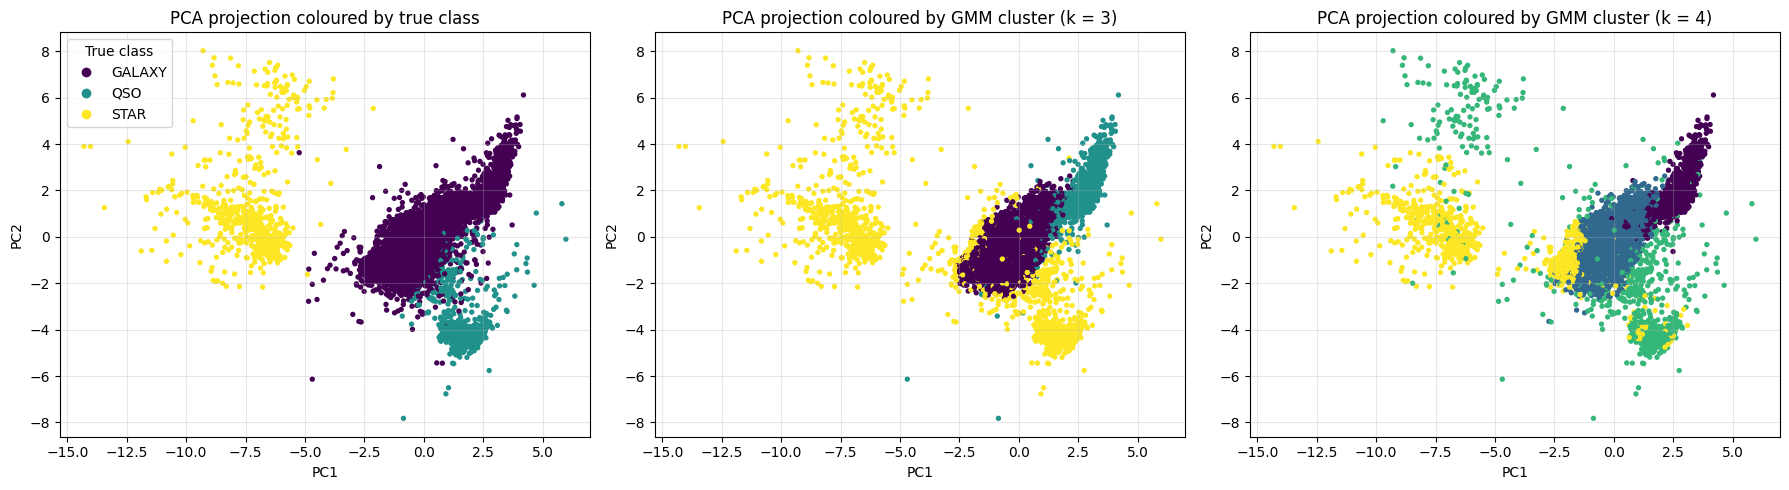

In [26]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

fig, axes = plt.subplots(1, len(candidate_ks) + 1, figsize=(6 * (len(candidate_ks) + 1), 5))

if len(candidate_ks) == 1:
    axes = np.array(axes).reshape(-1)

# Plot true labels
label_codes = pd.Categorical(y)
scatter = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=label_codes.codes, s=8)
axes[0].set_title("PCA projection coloured by true class")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].grid(alpha=0.3)
axes[0].legend(
    handles=scatter.legend_elements()[0],
    labels=list(label_codes.categories),
    title="True class",
    loc="best"
)

# Plot GMM branches
for i, k in enumerate(candidate_ks, start=1):
    labels = final_models[k].predict(X)
    axes[i].scatter(X_pca[:, 0], X_pca[:, 1], c=labels, s=8)
    axes[i].set_title(f"PCA projection coloured by GMM cluster (k = {k})")
    axes[i].set_xlabel("PC1")
    axes[i].set_ylabel("PC2")
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 11. interpretation 


1. **Why GMM was attempted**  
   GMM was selected because the astronomical classes were expected to have blurred boundaries and potentially correlated, non-spherical structure in colour–redshift space.

2. **Choice of \(K\)**  
   BIC was used as the primary criterion and AIC as a supporting criterion.  
   If \(K=3\) minimized BIC, the final model retained the domain-grounded three-component solution.  
   If another \(K\) performed better under BIC, both \(K=3\) and the BIC-optimal \(K\) were retained for direct comparison.

3. **Choice of covariance structure**  
   The covariance family was selected empirically using BIC/AIC.  
   If `full` performed best, that supports the idea that astronomical populations are better represented with flexible covariance structure rather than spherical or diagonal components.

4. **Evaluation outcome**    
   - weaker ARI/NMI with high-confidence assignments suggests model is in fact capturing structures but these structures are not able to separate the classes

5. **Scientific explanation of the result**  
   If stars and galaxies remain difficult to separate while QSOs are isolated more clearly, that is a plausible astrophysical outcome because redshift and colour often make QSOs stand out more strongly than the star–galaxy boundary.


## 12. References

1. **Tian, J., Yang, H., Cai, J., Yang, Y., Li, X., Yi, Z., & Wang, L. (2025).** 
**Progress in clustering algorithms for astronomical spectra over a decade. Astronomical Techniques and Instrument, 2(0), 1–16.**  
     
   https://doi.org/10.61977/ati2025030

2. **Kuhn, M. A., & Feigelson, E. D. (2017). Mixture models in astronomy. arXiv.**  
   
   https://arxiv.org/abs/1711.11101


3. **Ansari, Z. et al. (2021). _Mixture models for photometric redshifts_.**  
   Astronomy & Astrophysics  
   https://www.aanda.org/articles/aa/full_html/2021/06/aa39675-20/aa39675-20.html
